In [16]:
import csv
from datetime import datetime, timedelta
import random

# Function to generate a random date within a range
def random_date(start_date, end_date):
    time_between_dates = end_date - start_date
    days_between_dates = time_between_dates.days
    random_number_of_days = random.randrange(days_between_dates)
    random_date = start_date + timedelta(days=random_number_of_days)
    return random_date.strftime("%Y-%m-%d")

# Generating random data for the CSV file
data = []
categories = ['Fruit', 'Vegetable', 'Dairy', 'Meat', 'Grains', 'Beverages']
start_date = datetime(2023, 1, 1)
end_date = datetime(2024, 12, 31)

items = {
    'Fruit': ['Apple', 'Banana', 'Orange', 'Grapes', 'Mango', 'Pineapple', 'Watermelon', 'Strawberry', 'Kiwi', 'Peach'],
    'Vegetable': ['Tomato', 'Carrot', 'Broccoli', 'Spinach', 'Cucumber', 'Bell Pepper', 'Potato', 'Onion', 'Lettuce', 'Zucchini'],
    'Dairy': ['Milk', 'Cheese', 'Yogurt', 'Butter', 'Eggs', 'Cream', 'Cottage Cheese', 'Sour Cream', 'Margarine', 'Ricotta Cheese'],
    'Meat': ['Chicken', 'Beef', 'Pork', 'Turkey', 'Lamb', 'Duck', 'Salmon', 'Shrimp', 'Tuna', 'Sausage'],
    'Grains': ['Bread', 'Rice', 'Pasta', 'Oats', 'Quinoa', 'Barley', 'Couscous', 'Bulgur', 'Millet', 'Polenta'],
    'Beverages': ['Water', 'Coffee', 'Tea', 'Juice', 'Soda', 'Milkshake', 'Smoothie', 'Energy Drink', 'Sports Drink', 'Lemonade']
}

for category in categories:
    for item_name in items[category]:
        item = item_name
        quantity = random.randint(50, 200)
        manufacturing_date = random_date(start_date, end_date)
        expiry_date = random_date(datetime.strptime(manufacturing_date, "%Y-%m-%d"), end_date)
        price = round(random.uniform(100,1000), 2)
        quantity_sold = random.randint(0, quantity)
        total_sales = quantity_sold * price
        wasteage = quantity - quantity_sold
        data.append([item, category, quantity, manufacturing_date, expiry_date, price, quantity_sold, total_sales, wasteage])

# File path where the CSV file will be created
file_path = 'inventory_with_details.csv'

# Writing data to CSV file
with open(file_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['Item', 'Category', 'Quantity', 'Manufacturing_Date', 'Expiry_Date', 'Price', 'Quantity_Sold', 'Total_Sales', 'Wasteage'])
    writer.writerows(data)

date_range = pd.date_range(start='2023-01-01', end='2024-12-31', periods=len(df))
df['Date_Sold'] = np.random.choice(date_range, size=len(df))

# Save the updated DataFrame to a new CSV file
file_path = 'inventory'
df.to_csv(file_path, index=False)

print("CSV file created successfully!")

CSV file created successfully!


First few rows of the DataFrame:
     Item Category  Quantity Manufacturing_Date Expiry_Date   Price  \
0   Apple    Fruit       178         2023-03-22  2023-05-20  392.17   
1  Banana    Fruit        99         2023-12-28  2024-12-25  568.00   
2  Orange    Fruit       102         2024-07-25  2024-10-31  236.35   
3  Grapes    Fruit        77         2023-07-02  2023-11-16  468.29   
4   Mango    Fruit        88         2024-03-17  2024-08-04  808.62   

   Quantity_Sold  Total_Sales  Wasteage  
0            175     68629.75         3  
1              9      5112.00        90  
2             28      6617.80        74  
3             77     36058.33         0  
4             74     59837.88        14  

Basic statistics of numerical columns:
         Quantity       Price  Quantity_Sold    Total_Sales    Wasteage
count   60.000000   60.000000      60.000000      60.000000   60.000000
mean   116.350000  555.064167      59.216667   31353.162667   57.133333
std     43.776329  230.035839   

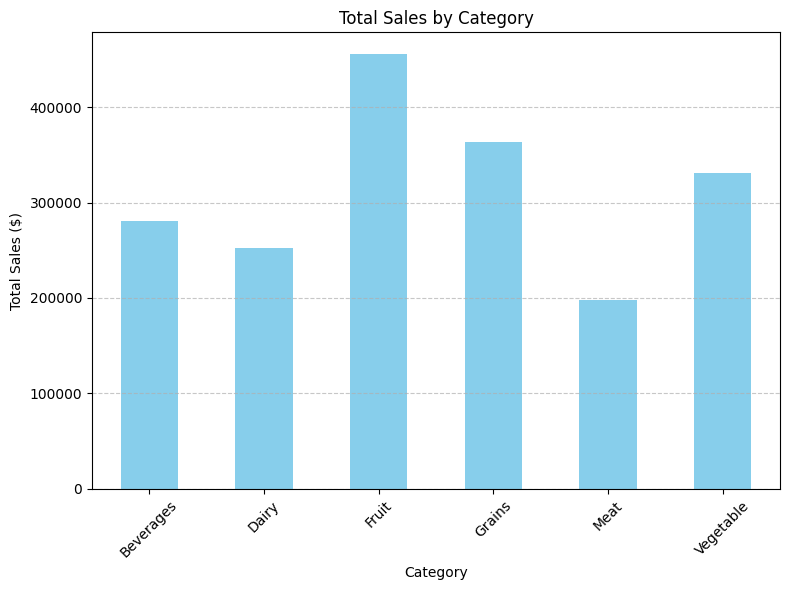

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file into a DataFrame
df = pd.read_csv('inventory_with_details.csv')

# Display the first few rows of the DataFrame
print("First few rows of the DataFrame:")
print(df.head())

# Basic statistics of numerical columns
print("\nBasic statistics of numerical columns:")
print(df.describe())

# Total sales by category
total_sales_by_category = df.groupby('Category')['Total_Sales'].sum()

# Plotting total sales by category
plt.figure(figsize=(8, 6))
total_sales_by_category.plot(kind='bar', color='skyblue')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


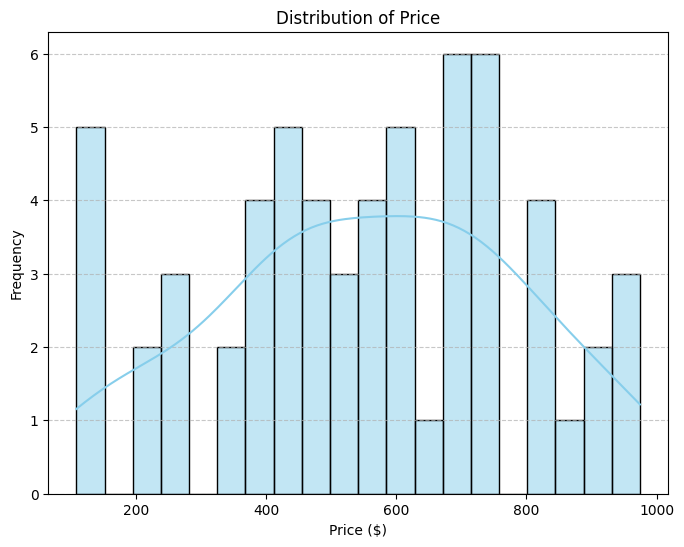

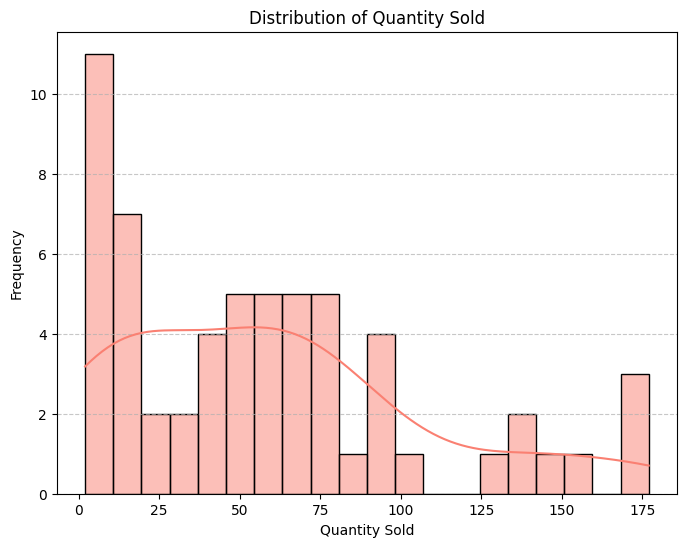

In [3]:
import seaborn as sns
# Load the CSV file into a DataFrame
df = pd.read_csv('inventory_with_details.csv')

# Distribution plot of Price
plt.figure(figsize=(8, 6))
sns.histplot(df['Price'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Price')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Distribution plot of Quantity Sold
plt.figure(figsize=(8, 6))
sns.histplot(df['Quantity_Sold'], bins=20, kde=True, color='salmon')
plt.title('Distribution of Quantity Sold')
plt.xlabel('Quantity Sold')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


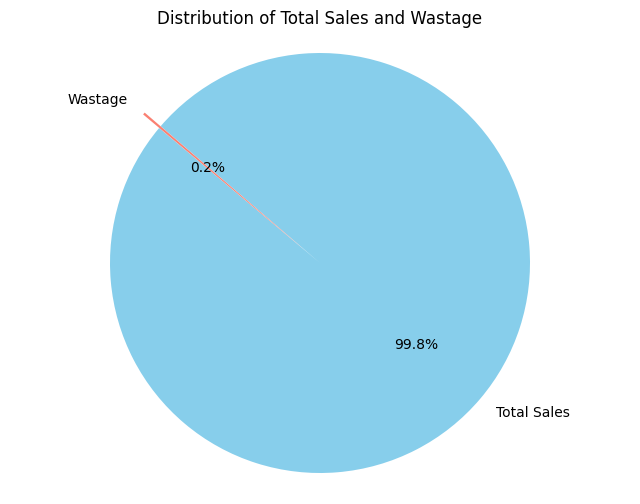

In [4]:
# Calculate total sales and wastage
total_sales = df['Total_Sales'].sum()
total_wastage = df['Wasteage'].sum()

# Pie chart
labels = ['Total Sales', 'Wastage']
sizes = [total_sales, total_wastage]
colors = ['skyblue', 'salmon']
explode = (0.1, 0)  # explode the 1st slice (Total Sales)

plt.figure(figsize=(8, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Total Sales and Wastage')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


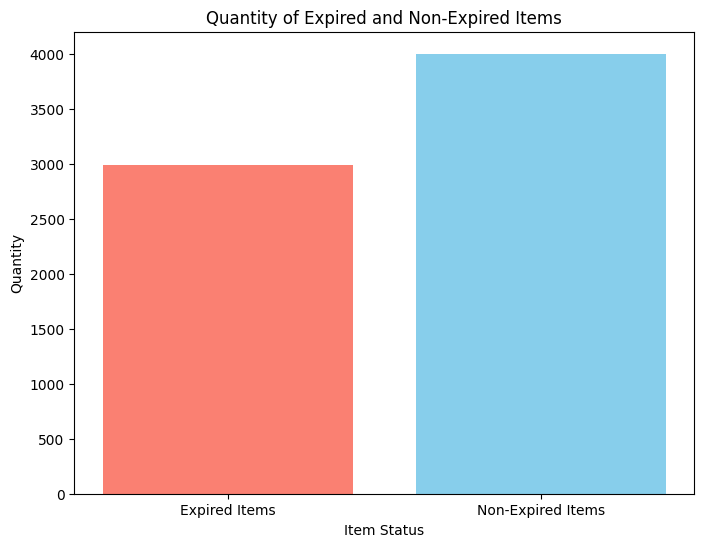

In [5]:
# Convert date columns to datetime format
df['Manufacturing_Date'] = pd.to_datetime(df['Manufacturing_Date'])
df['Expiry_Date'] = pd.to_datetime(df['Expiry_Date'])

# Get current date
current_date = pd.to_datetime('today')

# Filter expired items
expired_items = df[df['Expiry_Date'] < current_date]
non_expired_items = df[df['Expiry_Date'] >= current_date]

# Calculate the quantity of expired and non-expired items
quantity_expired = expired_items['Quantity'].sum()
quantity_non_expired = non_expired_items['Quantity'].sum()

# Create a bar chart to display the quantities
plt.figure(figsize=(8, 6))
plt.bar(['Expired Items', 'Non-Expired Items'], [quantity_expired, quantity_non_expired], color=['salmon', 'skyblue'])
plt.title('Quantity of Expired and Non-Expired Items')
plt.xlabel('Item Status')
plt.ylabel('Quantity')
plt.show()


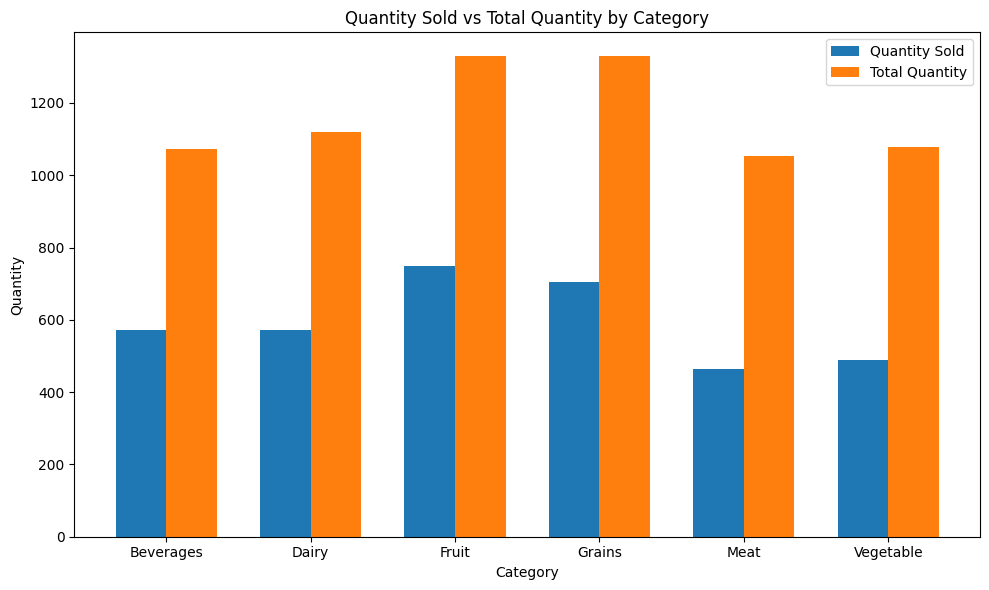

In [6]:
# Convert date columns to datetime format
df['Manufacturing_Date'] = pd.to_datetime(df['Manufacturing_Date'])
df['Expiry_Date'] = pd.to_datetime(df['Expiry_Date'])

# Group the DataFrame by category and sum the quantity sold and total quantity for each category
category_grouped = df.groupby('Category').agg({'Quantity_Sold': 'sum', 'Quantity': 'sum'}).reset_index()

# Plot the grouped bar chart
plt.figure(figsize=(10, 6))
bar_width = 0.35
index = category_grouped.index

plt.bar(index, category_grouped['Quantity_Sold'], bar_width, label='Quantity Sold')
plt.bar(index + bar_width, category_grouped['Quantity'], bar_width, label='Total Quantity')

plt.xlabel('Category')
plt.ylabel('Quantity')
plt.title('Quantity Sold vs Total Quantity by Category')
plt.xticks(index + bar_width / 2, category_grouped['Category'])
plt.legend()
plt.tight_layout()
plt.show()


In [7]:
# Filter the DataFrame for "Juice" item
juice_info = df[df['Item'] == 'Juice']

# Check the quantity and quantity sold for Juice
quantity_available = juice_info['Quantity'].values[0]
quantity_sold = juice_info['Quantity_Sold'].values[0]

print(f"Quantity available for Juice: {quantity_available}")
print(f"Quantity sold for Juice: {quantity_sold}")


Quantity available for Juice: 171
Quantity sold for Juice: 71


Mean Squared Error: 645542216.52
R-squared: -0.60


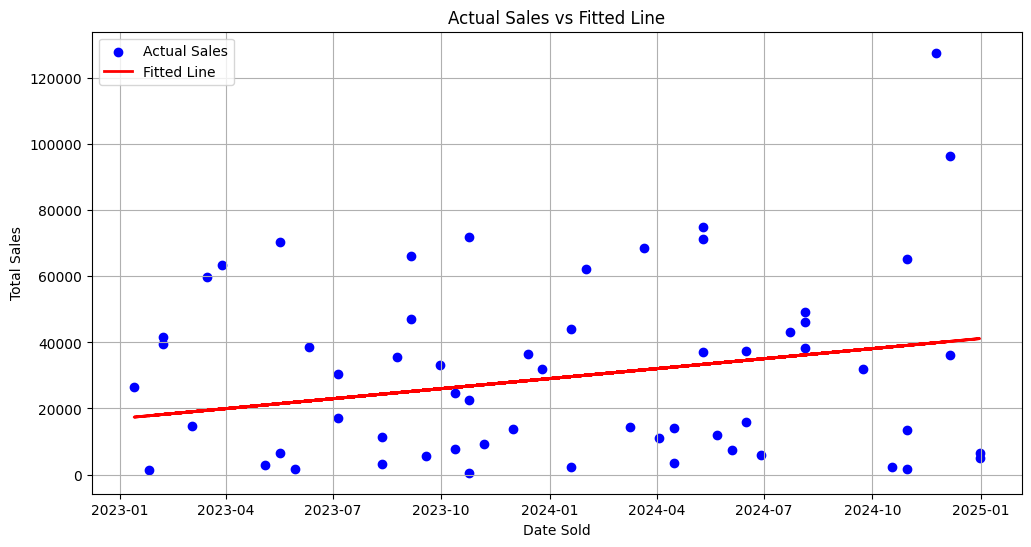

   Date_Sold  Predicted_Sales
0 2025-01-31     42182.121780
1 2025-02-28     43108.949686
2 2025-03-31     44135.080581
3 2025-04-30     45128.110480
4 2025-05-31     46154.241376


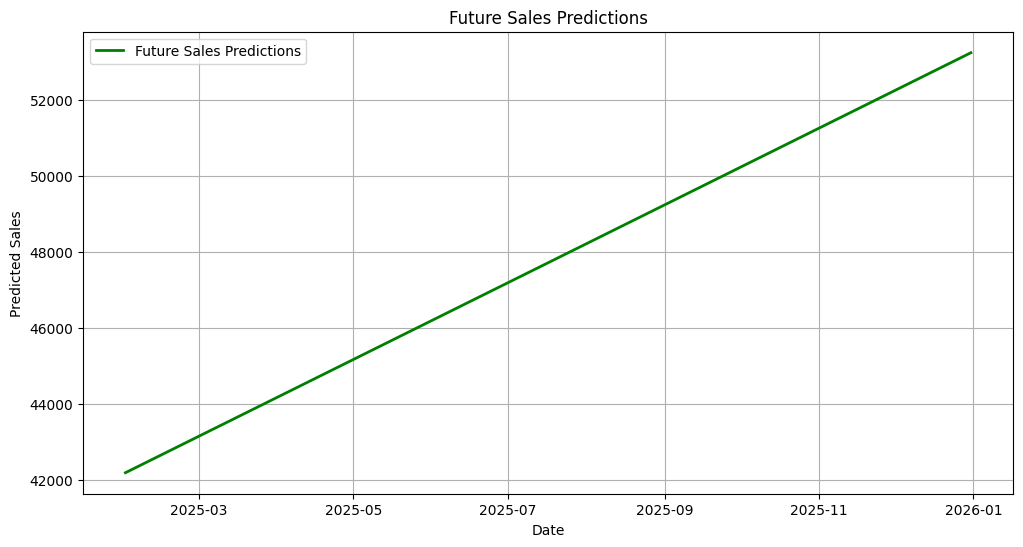

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Convert 'Date_Sold' to datetime format
df['Date_Sold'] = pd.to_datetime(df['Date_Sold'])

# Create a numerical feature based on 'Date_Sold'
df['Date_Sold_Ordinal'] = df['Date_Sold'].map(pd.Timestamp.toordinal)

# Create features and target variable
X = df[['Date_Sold_Ordinal']]
y = df['Total_Sales']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R-squared: {r2_score(y_test, y_pred):.2f}")

# Plot the results
plt.figure(figsize=(12, 6))
plt.scatter(df['Date_Sold'], df['Total_Sales'], color='blue', label='Actual Sales')
plt.plot(df['Date_Sold'], model.predict(df[['Date_Sold_Ordinal']]), color='red', linewidth=2, label='Fitted Line')
plt.title('Actual Sales vs Fitted Line')
plt.xlabel('Date Sold')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
plt.show()

# Predict future sales based on future dates
# Generate future dates (example: next year)
future_dates = pd.date_range(start='2025-01-01', end='2025-12-31', freq='M')
future_dates_ordinal = future_dates.map(pd.Timestamp.toordinal)
future_X = pd.DataFrame(future_dates_ordinal, columns=['Date_Sold_Ordinal'])
future_predictions = model.predict(future_X)

# Create a DataFrame for future predictions
future_sales_df = pd.DataFrame({
    'Date_Sold': future_dates,
    'Predicted_Sales': future_predictions
})

print(future_sales_df.head())  # Display the first few rows of future predictions

# Plot future sales predictions
plt.figure(figsize=(12, 6))
plt.plot(future_sales_df['Date_Sold'], future_sales_df['Predicted_Sales'], color='green', linewidth=2, label='Future Sales Predictions')
plt.title('Future Sales Predictions')
plt.xlabel('Date')
plt.ylabel('Predicted Sales')
plt.legend()
plt.grid(True)
plt.show()
